# 01 — Análise Exploratória do Dataset (EuroSAT RGB)

**Global Solution — Visão Computacional aplicada à Indústria Espacial**

Classificação de uso e cobertura do solo (LULC) a partir de imagens do satélite **Sentinel-2** (dataset EuroSAT RGB). O resultado da CNN é o componente de visão computacional de uma plataforma que agrega dados meteorológicos de sensoriamento remoto.

Este notebook: carrega o dataset, inspeciona as classes, visualiza amostras e define a divisão estratificada treino/validação/teste.

In [1]:
# >>> NO GOOGLE COLAB: rode ESTA célula primeiro (em ambiente local, pule) <<<
# Clona o repositório. NÃO instalamos requirements.txt no Colab: ele já traz
# TensorFlow, Keras, numpy, pandas, scikit-learn, matplotlib, seaborn e
# tensorflow-datasets em versões compatíveis entre si. Reinstalar versões
# fixas rebaixa o ml_dtypes/numpy e quebra o JAX do Colab.
!git clone https://github.com/luanmacea/gs-cnn-eurosat.git
%cd gs-cnn-eurosat

Cloning into 'gs-cnn-eurosat'...
remote: Enumerating objects: 61, done.
remote: Counting objects: 100% (61/61), done.
remote: Compressing objects: 100% (43/43), done.
remote: Total 61 (delta 29), reused 41 (delta 15), pack-reused 0 (from 0)
Receiving objects: 100% (61/61), 42.36 KiB | 7.06 MiB/s, done.
Resolving deltas: 100% (29/29), done.
/content/gs-cnn-eurosat


In [2]:
import sys, os
# Resolve a raiz do projeto de forma robusta (local OU Colab, com ou sem
# restart de runtime). Procura uma pasta que contenha 'src/'.
candidatos = [os.getcwd(), os.path.dirname(os.getcwd()), '/content/gs-cnn-eurosat']
ROOT = next((p for p in candidatos if os.path.isdir(os.path.join(p, 'src'))), os.getcwd())
os.chdir(ROOT)  # paths relativos (models/, reports/) consistentes
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)
print('Project root:', ROOT)

Project root: /content/gs-cnn-eurosat


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from src.data_loader import load_raw_data, make_splits, CLASS_NAMES, IMG_SIZE, NUM_CLASSES
sns.set_theme(style='whitegrid')

## Carregamento
Na primeira execução o TensorFlow Datasets baixa o EuroSAT (~90 MB) e o mantém em cache. As imagens são carregadas como `uint8 [0,255]` — a normalização acontece dentro do modelo (camada `Rescaling`).

In [4]:
images, labels = load_raw_data()
print('Imagens:', images.shape, images.dtype)
print('Labels :', labels.shape, '| nº de classes:', NUM_CLASSES)
print('Classes:', CLASS_NAMES)

Baixando EuroSAT RGB de: https://zenodo.org/records/7711810/files/EuroSAT_RGB.zip?download=1
  falhou (HTTPError: HTTP Error 403: Forbidden)
Baixando EuroSAT RGB de: https://zenodo.org/record/7711810/files/EuroSAT_RGB.zip?download=1
  falhou (HTTPError: HTTP Error 403: Forbidden)
Baixando EuroSAT RGB de: https://madm.dfki.de/files/sentinel/EuroSAT.zip
  falhou (URLError: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1010)>)
Fonte indisponivel -> _load_from_zip: URLError: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1010)>
Baixando EuroSAT RGB via Hugging Face (blanchon/EuroSAT_RGB)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/3.38k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/105M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/34.8M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/34.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16200 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5400 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5400 [00:00<?, ? examples/s]

Dataset carregado: 16200 imagens.
Imagens: (16200, 64, 64, 3) uint8
Labels : (16200,) | nº de classes: 10
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


## Distribuição de imagens por classe

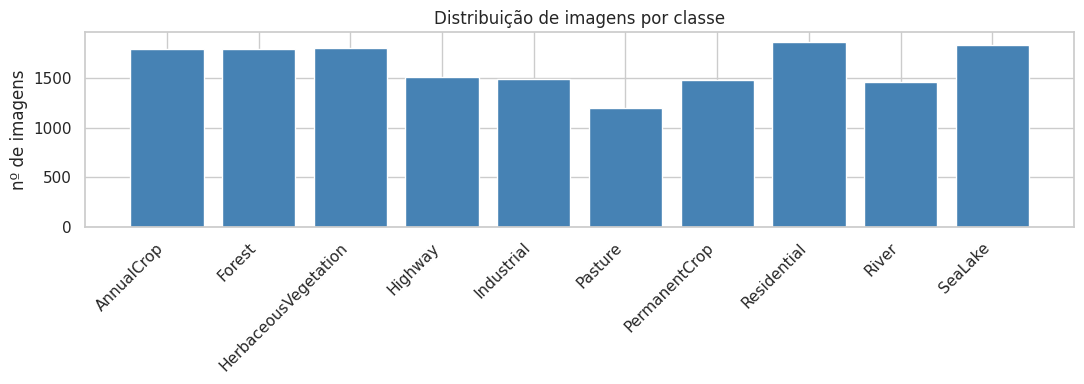

AnnualCrop              : 1791
Forest                  : 1787
HerbaceousVegetation    : 1799
Highway                 : 1505
Industrial              : 1492
Pasture                 : 1195
PermanentCrop           : 1481
Residential             : 1863
River                   : 1460
SeaLake                 : 1827


In [5]:
counts = Counter(labels.tolist())
plt.figure(figsize=(11, 4))
plt.bar([CLASS_NAMES[i] for i in range(NUM_CLASSES)],
        [counts[i] for i in range(NUM_CLASSES)], color='steelblue')
plt.xticks(rotation=45, ha='right')
plt.ylabel('nº de imagens'); plt.title('Distribuição de imagens por classe')
plt.tight_layout(); plt.show()
for i in range(NUM_CLASSES):
    print(f'{CLASS_NAMES[i]:24s}: {counts[i]}')

O EuroSAT é levemente desbalanceado (entre 2.000 e 3.000 imagens por classe). A divisão estratificada preserva essa proporção em treino, validação e teste.

## Amostras de cada classe

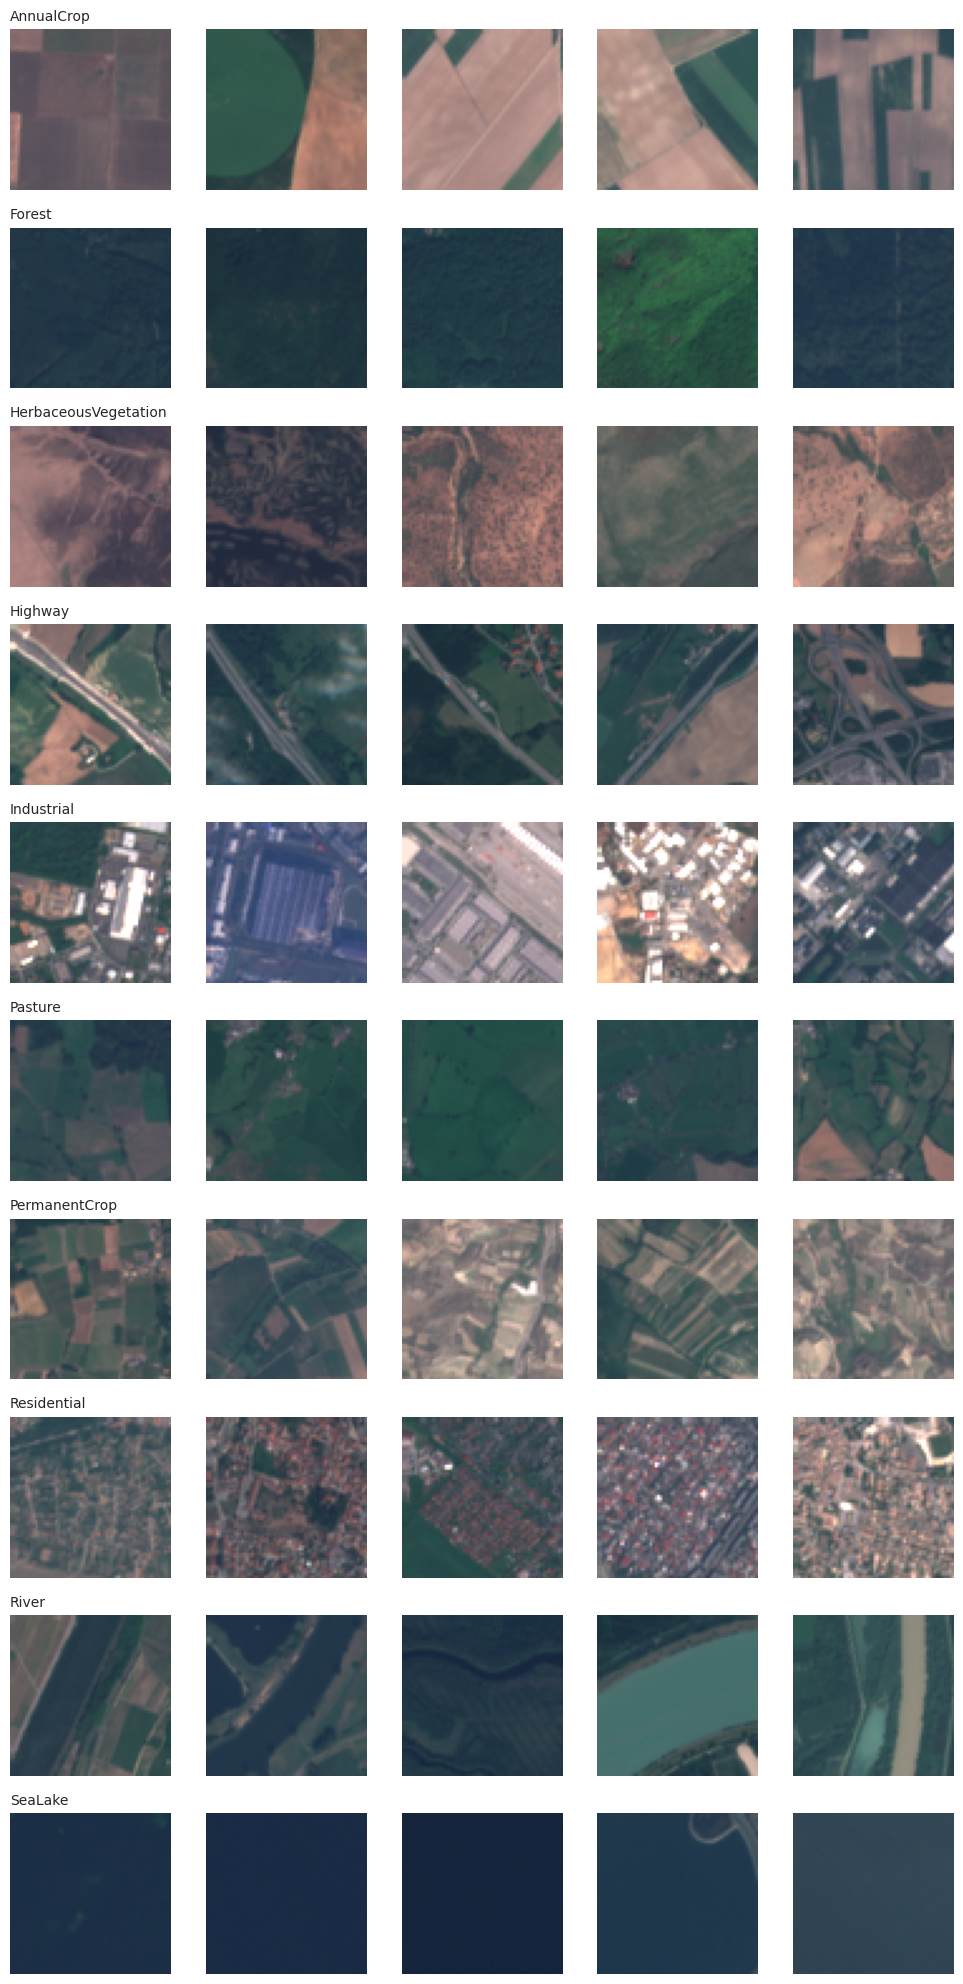

In [6]:
n_cols = 5
fig, axes = plt.subplots(NUM_CLASSES, n_cols, figsize=(10, 2 * NUM_CLASSES))
for c in range(NUM_CLASSES):
    idx = np.where(labels == c)[0][:n_cols]
    for j, k in enumerate(idx):
        axes[c, j].imshow(images[k])
        axes[c, j].axis('off')
    axes[c, 0].set_title(CLASS_NAMES[c], loc='left', fontsize=10)
plt.tight_layout(); plt.show()

## Estatísticas por canal (R, G, B)

In [7]:
flat = images.reshape(-1, 3).astype('float32')
for ci, cn in enumerate(['R', 'G', 'B']):
    print(f'Canal {cn}: média={flat[:, ci].mean():6.2f} | desvio={flat[:, ci].std():6.2f}')
print('\nValores em [0,255] -> por isso o modelo aplica Rescaling(1/255) na 1ª camada.')

Canal R: média= 79.74 | desvio= 48.80
Canal G: média= 88.00 | desvio= 32.40
Canal B: média= 94.43 | desvio= 27.20

Valores em [0,255] -> por isso o modelo aplica Rescaling(1/255) na 1ª camada.


## Divisão treino / validação / teste (estratificada — 70/15/15)
`seed=42` fixa a divisão para reprodutibilidade.

In [8]:
splits = make_splits(images, labels, seed=42)
for name, (x, y) in splits.items():
    print(f'{name:6s}: {len(x):6d} imagens')

print('\nProporção de classes por split (deve ser ~igual):')
for name, (x, y) in splits.items():
    dist = np.bincount(y, minlength=NUM_CLASSES) / len(y)
    print(f'{name:6s}:', np.round(dist, 3))

train :  11340 imagens
val   :   2430 imagens
test  :   2430 imagens

Proporção de classes por split (deve ser ~igual):
train : [0.11  0.11  0.111 0.093 0.092 0.074 0.091 0.115 0.09  0.113]
val   : [0.111 0.11  0.111 0.093 0.092 0.074 0.091 0.115 0.09  0.113]
test  : [0.111 0.11  0.111 0.093 0.092 0.074 0.091 0.115 0.09  0.113]


**Conclusão da EDA.** Dataset com 10 classes de uso do solo, levemente desbalanceado, imagens 64×64 RGB. A divisão estratificada mantém o balanceamento. Próximo passo: treinar a CNN-A (baseline) no notebook 02.